# Fiber photometry in Spyglass: DANDI:001935 (Uchida lab)

This notebook reads the Uchida lab's fiber photometry data (SFARI ARC, DANDI:001935) back out of a Spyglass database and works with it. It uses only the tables from the draft fiber-photometry schema, `spyglass.common.common_photometry` ([LorenFrankLab/spyglass PR #1637](https://github.com/LorenFrankLab/spyglass/pull/1637)).

**Where the data lives**

- **Database (MySQL):** the setup metadata (indicators, excitation sources, photodetector, optical fibers, brain regions, per-fiber configuration) and one row per recorded series. Each series row holds the name, unit, sample count, valid-time interval and fiber mapping.
- **NWB file on disk:** the fluorescence traces. `FiberPhotometryResponseSeries.fetch1_dataframe()` opens the file registered in `Nwbfile` and returns one trace as a time-indexed DataFrame.

**Sessions:** every session in the database with photometry rows. When this notebook was last run there were four lone-condition sessions: rats M4, M5 and M7 on day 1, and M4 on day 2. All four were converted from the original raw data with the current `uchida-lab-to-nwb` pipeline.

Section 1 checks what the database holds using queries alone. Section 2 fetches the traces and works with them: the walkthrough uses the first session, and the last part compares all of them.

**Running it:** Spyglass can't be imported on native Windows, so this notebook runs in the `spyglass-photometry` conda env inside WSL2. The database is the `spyglass-uchida-db` Docker container on port 3307; see `../docker-compose.yml` and `../dj_local_conf.json`.

In [1]:
from pathlib import Path

import datajoint as dj

# Load the connection config BEFORE importing spyglass: spyglass declares its schemas
# at import time and would otherwise connect with default settings (including TLS,
# which the local Docker MySQL doesn't use).
dj.config.load(str(Path("..") / "dj_local_conf.json"))
dj.conn(use_tls=False)

/home/algab/.conda/envs/spyglass-photometry/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources  # requires setuptools<82


[2026-09-28 12:16:05,465][INFO]: DataJoint is configured from /mnt/c/Users/algab/CatalystNeuro/uchida-lab-to-nwb/spyglass/dj_local_conf.json


[2026-09-28 12:16:05,475][INFO]: DataJoint 0.14.9 connected to root@127.0.0.1:3307


DataJoint connection (connected) root@127.0.0.1:3307

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.signal import find_peaks

from spyglass.common import (
    BrainRegion,
    ExcitationSource,
    FiberPhotometryConfig,
    FiberPhotometryResponseSeries,
    Indicator,
    IntervalList,
    OpticalFiber,
    Photodetector,
    Session,
    Subject,
)

pd.set_option("display.max_colwidth", 60)

## 1. What the database holds

Everything in this section comes from database queries; no NWB file is opened.

### Sessions and subjects

A session "has photometry" if it has at least one `FiberPhotometryConfig` row. The restriction `Session & FiberPhotometryConfig` keeps exactly those sessions.

In [3]:
photometry_sessions = Session & FiberPhotometryConfig

sessions = (
    pd.DataFrame(
        photometry_sessions.fetch(
            "nwb_file_name", "subject_id", "session_id", "session_start_time", as_dict=True
        )
    )
    .sort_values(["subject_id", "session_start_time"])
    .reset_index(drop=True)
)
display(sessions)

display((Subject & photometry_sessions).fetch(format="frame"))

,nwb_file_name,subject_id,session_id,session_start_time
0,sub-M4_ses-day-1-lone_.nwb,M4,day-1-lone,2024-06-24 13:58:40
1,sub-M4_ses-day-2-lone_.nwb,M4,day-2-lone,2024-06-25 14:02:08
2,sub-M5_ses-day-1-lone_.nwb,M5,day-1-lone,2024-06-24 14:35:50
3,sub-M7_ses-day-1-lone_.nwb,M7,day-1-lone,2024-06-24 15:53:46


,age,description,genotype,sex,species
subject_id,,,,,
M4,None,Experimental group: WT. Strain: Long Evans WT. Surgery d...,WT,M,Rattus norvegicus
M5,None,Experimental group: WT. Strain: Long Evans WT. Surgery d...,WT,M,Rattus norvegicus
M7,None,Experimental group: WT. Strain: Long Evans WT. Surgery d...,WT,M,Rattus norvegicus


### Hardware and reagents

The device tables are shared catalogs keyed by name. A session reuses a row when its NWB file describes the same device, so these tables stay small as sessions are added. The long free-text descriptions are left out here; `fetch()` without a projection returns them.

In [4]:
display(Indicator.proj("label", "manufacturer").fetch(format="frame"))
display(
    ExcitationSource.proj(
        "source_type", "excitation_mode", "wavelength_min_nm", "wavelength_max_nm"
    ).fetch(format="frame")
)
display(Photodetector.proj("detector_type", "gain", "gain_unit").fetch(format="frame"))
display(
    OpticalFiber.proj(
        "numerical_aperture", "core_diameter_in_um", "active_length_in_mm", "ferrule_model"
    ).fetch(format="frame")
)

,label,manufacturer
indicator_name,,
GRABDA3m,GRABDA3m,WZ Biosciences
tdTomato,tdTomato,Addgene


,source_type,excitation_mode,wavelength_min_nm,wavelength_max_nm
excitation_source_name,,,,
excitation_source_control,LED,one-photon,555.0,570.0
excitation_source_dopamine_signal,LED,one-photon,460.0,490.0


,detector_type,gain,gain_unit
photodetector_name,,,
photodetector_BFPD,CMOS,1.0,AU


,numerical_aperture,core_diameter_in_um,active_length_in_mm,ferrule_model
optical_fiber_name,,,,
optical_fiber_NAc,0.66,400.0,8.5,MFC_400/430-0.66_8.5mm_MF2.5_FLT
optical_fiber_TS,0.66,400.0,7.5,MFC_400/430-0.66_7.5mm_MF2.5_FLT


### Per-fiber configuration

`FiberPhotometryConfig` has one row per row of the NWB `FiberPhotometryTable`, meaning one per fiber × excitation channel. Each rat has two implants (nucleus accumbens and tail of striatum) co-expressing two indicators: GRABDA3m, a green dopamine sensor excited at 473 nm, and tdTomato, a red control fluorophore excited at 568 nm. That gives four rows per session.

The implant site is stored as a foreign key into Spyglass's shared `BrainRegion` lookup, so a join brings in the region name. Insertion coordinates are in mm from bregma; ML is signed by hemisphere.

In [5]:
config = (
    (FiberPhotometryConfig * BrainRegion)
    .proj(
        "region_name",
        "hemisphere",
        "indicator_name",
        "excitation_wavelength_in_nm",
        "emission_wavelength_in_nm",
        "optical_fiber_name",
        "ap_location",
        "ml_location",
        "dv_location",
    )
    .fetch(format="frame")
    .reset_index()
    .drop(columns="fiber_photometry_name")
)
config

,nwb_file_name,fiber_id,region_id,indicator_name,optical_fiber_name,hemisphere,ap_location,ml_location,dv_location,excitation_wavelength_in_nm,emission_wavelength_in_nm,region_name
0,sub-M4_ses-day-1-lone_.nwb,0,3,tdTomato,optical_fiber_NAc,right,1.15,2.2,-6.3,568.0,581.0,Nucleus Accumbens
1,sub-M4_ses-day-1-lone_.nwb,1,3,GRABDA3m,optical_fiber_NAc,right,1.15,2.2,-6.3,473.0,520.0,Nucleus Accumbens
2,sub-M4_ses-day-2-lone_.nwb,0,3,tdTomato,optical_fiber_NAc,right,1.15,2.2,-6.3,568.0,581.0,Nucleus Accumbens
3,sub-M4_ses-day-2-lone_.nwb,1,3,GRABDA3m,optical_fiber_NAc,right,1.15,2.2,-6.3,473.0,520.0,Nucleus Accumbens
4,sub-M5_ses-day-1-lone_.nwb,0,3,tdTomato,optical_fiber_NAc,right,1.15,2.2,-6.3,568.0,581.0,Nucleus Accumbens
5,sub-M5_ses-day-1-lone_.nwb,1,3,GRABDA3m,optical_fiber_NAc,right,1.15,2.2,-6.3,473.0,520.0,Nucleus Accumbens
6,sub-M7_ses-day-1-lone_.nwb,0,3,tdTomato,optical_fiber_NAc,left,1.15,-2.2,-6.3,568.0,581.0,Nucleus Accumbens
7,sub-M7_ses-day-1-lone_.nwb,1,3,GRABDA3m,optical_fiber_NAc,left,1.15,-2.2,-6.3,473.0,520.0,Nucleus Accumbens
8,sub-M4_ses-day-1-lone_.nwb,2,4,tdTomato,optical_fiber_TS,left,3.15,-5.2,-4.5,568.0,581.0,Tail of Striatum
9,sub-M4_ses-day-1-lone_.nwb,3,4,GRABDA3m,optical_fiber_TS,left,3.15,-5.2,-4.5,473.0,520.0,Tail of Striatum


### Recorded series

Each session has four `FiberPhotometryResponseSeries`, one per excitation channel and processing stage:

| Series | Channel | Processing | Rate |
|---|---|---|---|
| `FiberPhotometryRawDopamineSignal` | GRABDA3m, 473 nm | demodulated Doric output | ~30 Hz |
| `FiberPhotometryRawControlSignal` | tdTomato, 568 nm | demodulated Doric output | ~30 Hz |
| `FiberPhotometryInterpolatedDopamineSignal` | GRABDA3m, 473 nm | resampled to the camera clock | ~50 Hz |
| `FiberPhotometryInterpolatedControl` | tdTomato, 568 nm | resampled to the camera clock | ~50 Hz |

Every series has two columns, NAc and TS. The table stores the sample count, and the linked `IntervalList` row stores the recorded time span, so the effective sampling rate can be derived without opening the file.

In [6]:
series = pd.DataFrame(
    (FiberPhotometryResponseSeries * IntervalList).fetch(
        "nwb_file_name", "name", "unit", "num_samples", "valid_times", as_dict=True
    )
)
series["start_s"] = series["valid_times"].map(lambda vt: vt[0][0])
series["end_s"] = series["valid_times"].map(lambda vt: vt[-1][1])
series["rate_hz"] = (series["num_samples"] - 1) / (series["end_s"] - series["start_s"])
series = (
    series.drop(columns="valid_times")
    .sort_values(["nwb_file_name", "name"])
    .reset_index(drop=True)
)
series.round({"start_s": 3, "end_s": 3, "rate_hz": 2})

,nwb_file_name,name,num_samples,unit,start_s,end_s,rate_hz
0,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryInterpolatedControl,90074,F,3.216,1809.369,49.87
1,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryInterpolatedDopamineSignal,90074,F,3.216,1809.369,49.87
2,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryRawControlSignal,54456,a.u.,3.216,1811.122,30.12
3,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryRawDopamineSignal,54455,a.u.,3.233,1811.106,30.12
4,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryInterpolatedControl,90074,F,3.007,1809.155,49.87
5,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryInterpolatedDopamineSignal,90074,F,3.007,1809.155,49.87
6,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryRawControlSignal,54574,a.u.,3.008,1814.831,30.12
7,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryRawDopamineSignal,54573,a.u.,3.024,1814.815,30.12
8,sub-M5_ses-day-1-lone_.nwb,FiberPhotometryInterpolatedControl,90074,F,5.876,1812.022,49.87
9,sub-M5_ses-day-1-lone_.nwb,FiberPhotometryInterpolatedDopamineSignal,90074,F,5.876,1812.022,49.87


### Which fiber each column records

A two-column trace is only interpretable if you know which column is which fiber. The `FiberPhotometryResponseSeries.Fiber` part table maps each column (`region_index`) to its `FiberPhotometryConfig` row. Joining through the config and `BrainRegion` tables gives the region and indicator for every column of every series.

In [7]:
fiber_map = (
    pd.DataFrame(
        (
            FiberPhotometryResponseSeries.Fiber
            * FiberPhotometryResponseSeries.proj("name")
            * FiberPhotometryConfig.proj("indicator_name", "region_id")
            * BrainRegion.proj("region_name")
        ).fetch(
            "nwb_file_name", "name", "region_index", "region_name", "indicator_name",
            as_dict=True,
        )
    )
    .sort_values(["nwb_file_name", "name", "region_index"])
    .reset_index(drop=True)
)
fiber_map

,nwb_file_name,region_index,name,indicator_name,region_name
0,sub-M4_ses-day-1-lone_.nwb,0,FiberPhotometryInterpolatedControl,tdTomato,Nucleus Accumbens
1,sub-M4_ses-day-1-lone_.nwb,1,FiberPhotometryInterpolatedControl,tdTomato,Tail of Striatum
2,sub-M4_ses-day-1-lone_.nwb,0,FiberPhotometryInterpolatedDopamineSignal,GRABDA3m,Nucleus Accumbens
3,sub-M4_ses-day-1-lone_.nwb,1,FiberPhotometryInterpolatedDopamineSignal,GRABDA3m,Tail of Striatum
4,sub-M4_ses-day-1-lone_.nwb,0,FiberPhotometryRawControlSignal,tdTomato,Nucleus Accumbens
5,sub-M4_ses-day-1-lone_.nwb,1,FiberPhotometryRawControlSignal,tdTomato,Tail of Striatum
6,sub-M4_ses-day-1-lone_.nwb,0,FiberPhotometryRawDopamineSignal,GRABDA3m,Nucleus Accumbens
7,sub-M4_ses-day-1-lone_.nwb,1,FiberPhotometryRawDopamineSignal,GRABDA3m,Tail of Striatum
8,sub-M4_ses-day-2-lone_.nwb,0,FiberPhotometryInterpolatedControl,tdTomato,Nucleus Accumbens
9,sub-M4_ses-day-2-lone_.nwb,1,FiberPhotometryInterpolatedControl,tdTomato,Tail of Striatum


### Completeness checks

The checks below state what every session in this dataset should look like and assert it for each session in the database, using only the query results above. A failure names the session and what's wrong, so the notebook doubles as a test after new sessions are inserted.

In [8]:
EXPECTED_REGIONS = {"Nucleus Accumbens", "Tail of Striatum"}
EXPECTED_EXCITATION_NM = {"GRABDA3m": 473.0, "tdTomato": 568.0}
# series name -> (indicator it records, expected sampling rate range in Hz)
EXPECTED_SERIES = {
    "FiberPhotometryRawDopamineSignal": ("GRABDA3m", (25, 35)),
    "FiberPhotometryRawControlSignal": ("tdTomato", (25, 35)),
    "FiberPhotometryInterpolatedDopamineSignal": ("GRABDA3m", (45, 55)),
    "FiberPhotometryInterpolatedControl": ("tdTomato", (45, 55)),
}

assert len(sessions) > 0, "No sessions with fiber photometry in the database"

for nwb_file_name in sessions["nwb_file_name"]:
    cfg = config[config["nwb_file_name"] == nwb_file_name]
    ser = series[series["nwb_file_name"] == nwb_file_name].set_index("name")
    fib = fiber_map[fiber_map["nwb_file_name"] == nwb_file_name]

    # Configuration: two regions x two indicators, known wavelengths, real hemisphere
    assert len(cfg) == 4, f"{nwb_file_name}: {len(cfg)} config rows, expected 4"
    assert set(cfg["region_name"]) == EXPECTED_REGIONS, f"{nwb_file_name}: regions {set(cfg['region_name'])}"
    assert (cfg.groupby("region_name")["indicator_name"].apply(set) == set(EXPECTED_EXCITATION_NM)).all(), (
        f"{nwb_file_name}: each region should carry both indicators"
    )
    for indicator, wavelength in EXPECTED_EXCITATION_NM.items():
        got = set(cfg.loc[cfg["indicator_name"] == indicator, "excitation_wavelength_in_nm"])
        assert got == {wavelength}, f"{nwb_file_name}: {indicator} excitation {got}, expected {wavelength}"
    assert cfg["hemisphere"].isin(["left", "right"]).all(), f"{nwb_file_name}: hemisphere missing"

    # Series: the four expected ones, plausible sampling rates
    assert set(ser.index) == set(EXPECTED_SERIES), f"{nwb_file_name}: series {sorted(ser.index)}"
    for name, (indicator, (lo, hi)) in EXPECTED_SERIES.items():
        rate = ser.loc[name, "rate_hz"]
        assert lo <= rate <= hi, f"{nwb_file_name}: {name} at {rate:.2f} Hz, expected {lo}-{hi}"

        # Fiber mapping: column 0 and 1 cover both regions, all with the right indicator
        cols = fib[fib["name"] == name]
        assert sorted(cols["region_index"]) == [0, 1], f"{nwb_file_name}: {name} columns {list(cols['region_index'])}"
        assert set(cols["region_name"]) == EXPECTED_REGIONS, f"{nwb_file_name}: {name} regions {set(cols['region_name'])}"
        assert set(cols["indicator_name"]) == {indicator}, f"{nwb_file_name}: {name} indicator {set(cols['indicator_name'])}"

print(f"All completeness checks passed for {len(sessions)} session(s):")
for _, row in sessions.iterrows():
    print(f"  {row['subject_id']}  {row['session_id']}  ({row['nwb_file_name']})")

All completeness checks passed for 4 session(s):
  M4  day-1-lone  (sub-M4_ses-day-1-lone_.nwb)
  M4  day-2-lone  (sub-M4_ses-day-2-lone_.nwb)
  M5  day-1-lone  (sub-M5_ses-day-1-lone_.nwb)
  M7  day-1-lone  (sub-M7_ses-day-1-lone_.nwb)


## 2. Working with the traces

The traces are fetched through Spyglass rather than by opening files by hand: restrict `FiberPhotometryResponseSeries` to one row, then call `fetch1_dataframe()`. Spyglass finds the NWB file through the `Nwbfile` table and returns a DataFrame indexed by time in seconds. Its columns are labeled from the `.Fiber` mapping as `<region>_<excitation wavelength>nm`.

Colors in the figures: where control and dopamine signal share an axis, control (tdTomato) is grey and the dopamine signal (GRABDA3m) is green. Elsewhere, color identifies the brain region: blue for nucleus accumbens (NAc) and orange for tail of striatum (TS).

In [9]:
def fetch_trace(nwb_file_name, series_name):
    """One response series as a time-indexed DataFrame (reads the NWB file via Spyglass)."""
    key = {"nwb_file_name": nwb_file_name, "name": series_name}
    return (FiberPhotometryResponseSeries & key).fetch1_dataframe()


def region_of(column):
    """'Nucleus Accumbens_473nm' -> 'Nucleus Accumbens'."""
    return column.rsplit("_", 1)[0]


REGION_COLORS = {"Nucleus Accumbens": "#2a78d6", "Tail of Striatum": "#eb6834"}
REGION_SHORT = {"Nucleus Accumbens": "NAc", "Tail of Striatum": "TS"}
SURFACE, INK, INK_2, MUTED, GRID, AXIS = (
    "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
)

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": AXIS,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titlelocation": "left",
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "axes.grid.axis": "y",
        "axes.axisbelow": True,
        "grid.color": GRID,
        "grid.linewidth": 0.6,
        "xtick.color": MUTED,
        "ytick.color": MUTED,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.frameon": False,
        "legend.fontsize": 9,
        "legend.labelcolor": INK_2,
        "font.family": "sans-serif",
    }
)

### One session, whole recording

These figures follow the DANDI:001935 tutorial. There is one panel per brain region, and the tdTomato control (grey) and GRABDA3m dopamine signal (green) share one axis. That way their absolute levels and drift can be compared directly. The first figure shows the raw Doric series, the second the camera-clock (interpolated) series.

In [10]:
session = sessions.iloc[0]
nwb_file_name = session["nwb_file_name"]
session_label = f"{session['subject_id']}, {session['session_id']}"

raw_dopamine = fetch_trace(nwb_file_name, "FiberPhotometryRawDopamineSignal")
raw_control = fetch_trace(nwb_file_name, "FiberPhotometryRawControlSignal")
dopamine = fetch_trace(nwb_file_name, "FiberPhotometryInterpolatedDopamineSignal")
control = fetch_trace(nwb_file_name, "FiberPhotometryInterpolatedControl")
print(f"{session_label}: raw dopamine {raw_dopamine.shape}, raw control {raw_control.shape}")
print(f"{session_label}: camera-clock dopamine {dopamine.shape}, camera-clock control {control.shape}")
dopamine.head()

M4, day-1-lone: raw dopamine (54455, 2), raw control (54456, 2)
M4, day-1-lone: camera-clock dopamine (90074, 2), camera-clock control (90074, 2)


,Nucleus Accumbens_473nm,Tail of Striatum_473nm
time,,
3.216,7705.425520,4064.791563
11.231,7661.496721,4041.627613
11.251,7661.226907,4040.964909
11.271,7660.957092,4040.302205
11.291,7673.386547,4040.826846


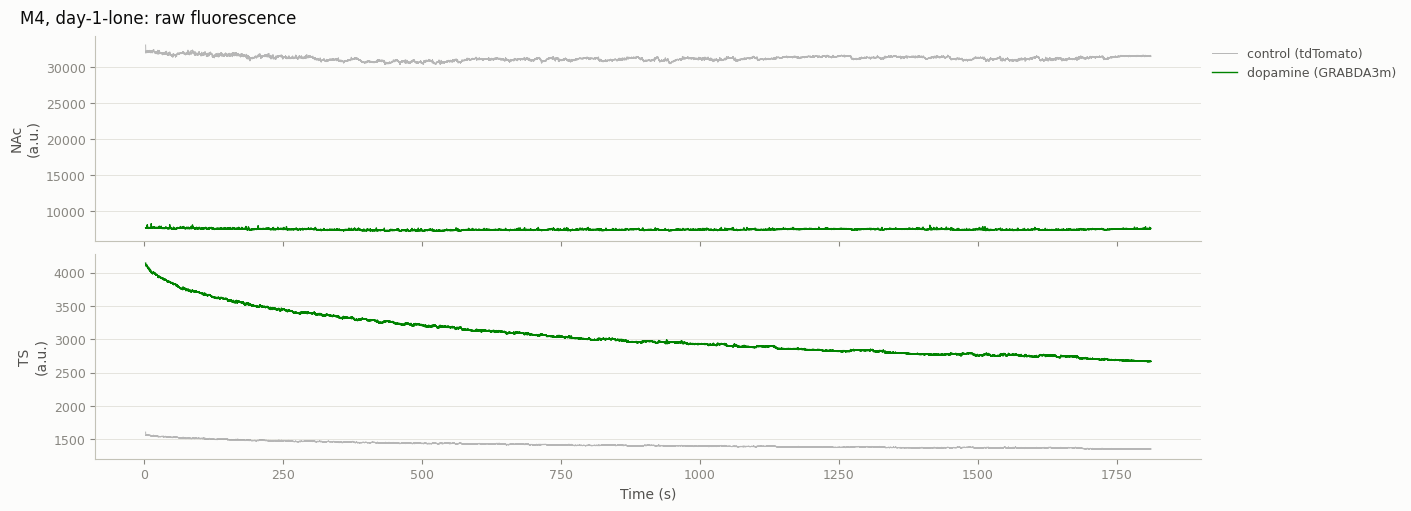

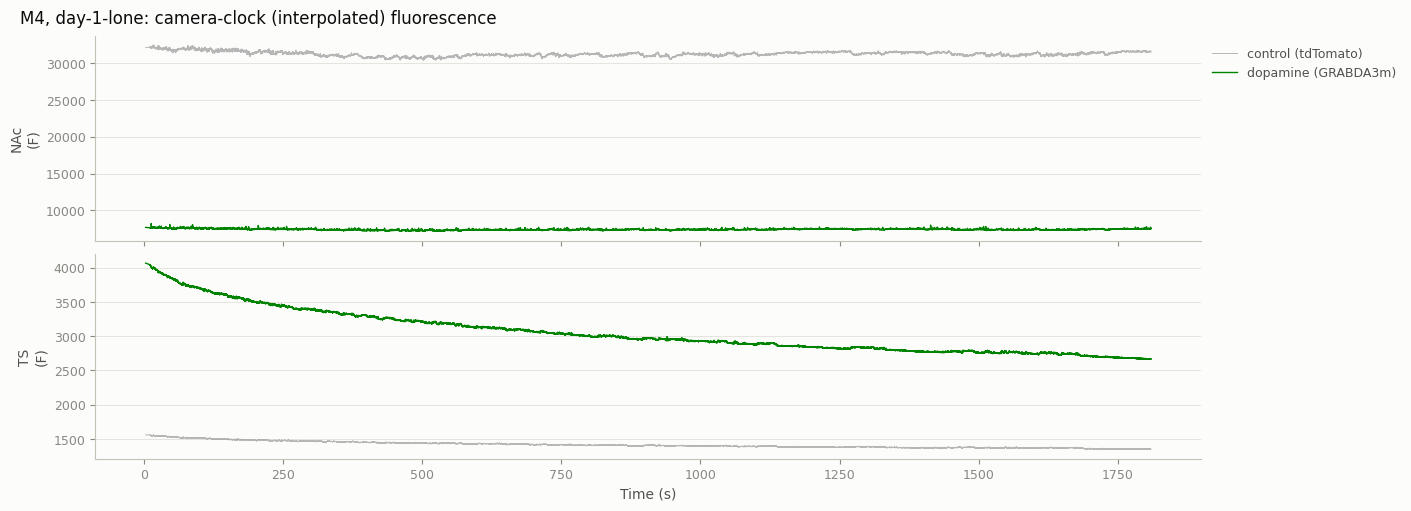

In [11]:
CONTROL_COLOR = "#999999"  # tdTomato control, grey
SIGNAL_COLOR = "#008300"  # GRABDA3m dopamine signal, green


def plot_control_and_signal(control, dopamine, title, unit):
    """One panel per region; control (grey) and dopamine signal (green) on a shared y-axis."""
    regions = list(REGION_COLORS)
    fig, axes = plt.subplots(
        len(regions), 1, figsize=(14, 2.5 * len(regions)), sharex=True, constrained_layout=True
    )
    for ax, region in zip(axes, regions):
        ctl_col = next(c for c in control.columns if region_of(c) == region)
        sig_col = next(c for c in dopamine.columns if region_of(c) == region)
        ax.plot(control.index, control[ctl_col], color=CONTROL_COLOR, lw=0.7, alpha=0.7,
                label="control (tdTomato)", rasterized=True)
        ax.plot(dopamine.index, dopamine[sig_col], color=SIGNAL_COLOR, lw=1.0,
                label="dopamine (GRABDA3m)", rasterized=True)
        ax.set_ylabel(f"{REGION_SHORT[region]}\n({unit})")
    axes[0].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, x=0.01, ha="left", color=INK)
    return fig, axes


raw_unit, interp_unit = (
    series.set_index(["nwb_file_name", "name"])
    .loc[[(nwb_file_name, "FiberPhotometryRawDopamineSignal"),
          (nwb_file_name, "FiberPhotometryInterpolatedDopamineSignal")], "unit"]
)

plot_control_and_signal(
    raw_control, raw_dopamine, f"{session_label}: raw fluorescence", raw_unit
)
plt.show()

plot_control_and_signal(
    control, dopamine, f"{session_label}: camera-clock (interpolated) fluorescence", interp_unit
)
plt.show()

### Raw and camera-clock series share one time base

The raw series come straight from the Doric system at about 30 Hz. The interpolated series are the same signal resampled at each video frame (about 50 Hz), so photometry can be lined up frame by frame with video and pose. Both are stored on the session clock, which allows overlaying them directly. In a five-second window the interpolated line should pass through the raw samples.

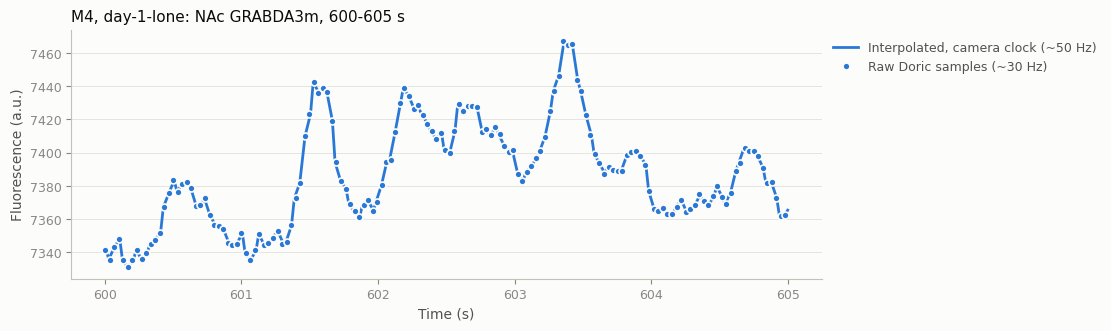

Median relative difference, raw re-interpolated vs stored interpolated: 6.72e-05


In [12]:
window = (600.0, 605.0)  # seconds on the session clock
column = "Nucleus Accumbens_473nm"
raw_win = raw_dopamine.loc[window[0]:window[1], column]
interp_win = dopamine.loc[window[0]:window[1], column]

fig, ax = plt.subplots(figsize=(11, 3.2), constrained_layout=True)
color = REGION_COLORS["Nucleus Accumbens"]
ax.plot(interp_win.index, interp_win, color=color, linewidth=2, label="Interpolated, camera clock (~50 Hz)")
ax.plot(
    raw_win.index, raw_win, linestyle="none", marker="o", markersize=5,
    markerfacecolor=color, markeredgecolor=SURFACE, markeredgewidth=1.2,
    label="Raw Doric samples (~30 Hz)",
)
ax.set_title(f"{session_label}: NAc GRABDA3m, {window[0]:.0f}-{window[1]:.0f} s")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.show()

# Interpolating the raw samples onto the camera timestamps should reproduce the stored
# interpolated series closely if the two share a clock.
raw_on_camera = np.interp(interp_win.index, raw_win.index, raw_win.to_numpy())
rel_err = np.abs(raw_on_camera - interp_win.to_numpy()) / np.abs(interp_win.to_numpy())
print(f"Median relative difference, raw re-interpolated vs stored interpolated: {np.median(rel_err):.2e}")

### Checking the time axis for gaps

Spyglass records each series' valid times in `IntervalList` as a single `[first, last]` interval, which assumes acquisition was continuous. The check below looks at the actual timestamps of every series in every session and lists any step longer than five times that series' median sampling interval.

The raw series are continuous in every session. In three of the four sessions, the camera-clock series start with one isolated sample and the rest follow about 8 s later. Those are the sessions with 90,074 camera-clock samples; M7, which has exactly 90,000, has no gap. The hole is inside the `IntervalList` interval, so analyses of the camera-clock series should start after it. It comes from how the conversion assigns timestamps to the interpolated data, not from Spyglass.

In [13]:
def find_gaps(times, factor=5.0):
    """(start, end) of every step longer than `factor` x the median sampling interval."""
    dt = np.diff(times)
    big = np.flatnonzero(dt > factor * np.median(dt))
    return [(times[i], times[i + 1]) for i in big]


gap_rows = []
for nwb_file_name_i in sessions["nwb_file_name"]:
    for series_name in EXPECTED_SERIES:
        times = fetch_trace(nwb_file_name_i, series_name).index.to_numpy()
        found = find_gaps(times)
        gap_rows.append(
            {
                "nwb_file_name": nwb_file_name_i,
                "name": series_name,
                "n_gaps": len(found),
                "gaps_s": [(round(a, 3), round(b, 3)) for a, b in found],
                # first timestamp after the last gap: where continuous data begins
                "continuous_from_s": round(found[-1][1] if found else times[0], 3),
            }
        )
gaps = pd.DataFrame(gap_rows)
gaps

,nwb_file_name,name,n_gaps,gaps_s,continuous_from_s
0,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryRawDopamineSignal,0,[],3.233
1,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryRawControlSignal,0,[],3.216
2,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryInterpolatedDopamineSignal,1,"[(3.216, 11.231)]",11.231
3,sub-M4_ses-day-1-lone_.nwb,FiberPhotometryInterpolatedControl,1,"[(3.216, 11.231)]",11.231
4,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryRawDopamineSignal,0,[],3.024
5,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryRawControlSignal,0,[],3.008
6,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryInterpolatedDopamineSignal,1,"[(3.007, 11.017)]",11.017
7,sub-M4_ses-day-2-lone_.nwb,FiberPhotometryInterpolatedControl,1,"[(3.007, 11.017)]",11.017
8,sub-M5_ses-day-1-lone_.nwb,FiberPhotometryRawDopamineSignal,0,[],5.893
9,sub-M5_ses-day-1-lone_.nwb,FiberPhotometryRawControlSignal,0,[],5.877


### From fluorescence to ΔF/F

Photometry traces drift. The fluorophores bleach over the session (visible in TS above), and movement changes how much light reaches the fiber. The co-expressed tdTomato doesn't respond to dopamine but shares those artifacts, so it can serve as a reference. For each region, the tdTomato trace is fit to the GRABDA3m trace by least squares, and ΔF/F is the GRABDA3m signal relative to that fit:

ΔF/F = (GRABDA3m − fitted tdTomato) / fitted tdTomato × 100 %

**This is an illustration of working with the data, not the lab's analysis.** The lab's own ΔF/F is deliberately not in these NWB files until they confirm how it was computed, and a red reference like tdTomato behaves differently from an isosbestic control. Treat the numbers below as a demonstration.

The analysis window comes from the database. It starts from the series' `IntervalList` valid times, and the start is then moved past any timestamp gap found above.

In [14]:
def analysis_window(nwb_file_name, series_name):
    """[start, end] from the series' IntervalList valid times, with start moved past any timestamp gap."""
    key = {"nwb_file_name": nwb_file_name, "name": series_name}
    interval_list_name = (FiberPhotometryResponseSeries & key).fetch1("interval_list_name")
    valid_times = (
        IntervalList
        & {"nwb_file_name": nwb_file_name, "interval_list_name": interval_list_name}
    ).fetch1("valid_times")
    start, end = valid_times[0][0], valid_times[-1][1]
    continuous_from = gaps.set_index(["nwb_file_name", "name"]).loc[
        (nwb_file_name, series_name), "continuous_from_s"
    ]
    return max(start, continuous_from), end


def compute_dff(dopamine, control):
    """Per-region ΔF/F (%) of GRABDA3m against a least-squares fit of tdTomato."""
    assert dopamine.index.equals(control.index), "dopamine and control must share timestamps"
    dff = {}
    for region in REGION_COLORS:
        green = dopamine[next(c for c in dopamine.columns if region_of(c) == region)].to_numpy()
        red = control[next(c for c in control.columns if region_of(c) == region)].to_numpy()
        slope, intercept = np.polyfit(red, green, 1)
        fitted = slope * red + intercept
        dff[region] = (green - fitted) / fitted * 100
    return pd.DataFrame(dff, index=dopamine.index)


start, end = analysis_window(nwb_file_name, "FiberPhotometryInterpolatedDopamineSignal")
print(f"{session_label}: analysis window {start:.3f}-{end:.3f} s ({(end - start) / 60:.1f} min)")

dff = compute_dff(dopamine.loc[start:end], control.loc[start:end])
dff.describe().round(3)

M4, day-1-lone: analysis window 11.231-1809.369 s (30.0 min)


,Nucleus Accumbens,Tail of Striatum
count,90073.000,90073.000
mean,0.000,0.004
std,0.599,0.830
min,-1.395,-3.029
25%,-0.360,-0.578
50%,-0.110,0.048
75%,0.203,0.575
max,7.521,2.873


### Dopamine transients

A simple way to summarize a ΔF/F trace is to count its transients. The whole-session tdTomato fit above doesn't remove everything: in TS the two indicators bleach at different rates, so its ΔF/F still wanders slowly by a percent or two. Transients are therefore measured against a local baseline, a 30 s rolling median, instead of the session median.

A transient is a peak whose robust z-score above that local baseline exceeds 3. The robust z-score divides by 1.4826 × the median absolute deviation, which a few large events can't inflate the way they would a standard deviation. Peaks must also be at least 0.5 s apart.

The figure shows one minute of ΔF/F per region on a shared y-axis, since both are in percent, with the local baseline dashed and detected transients marked.

NAc: 410 transients, 13.7 per minute
TS: 71 transients, 2.4 per minute


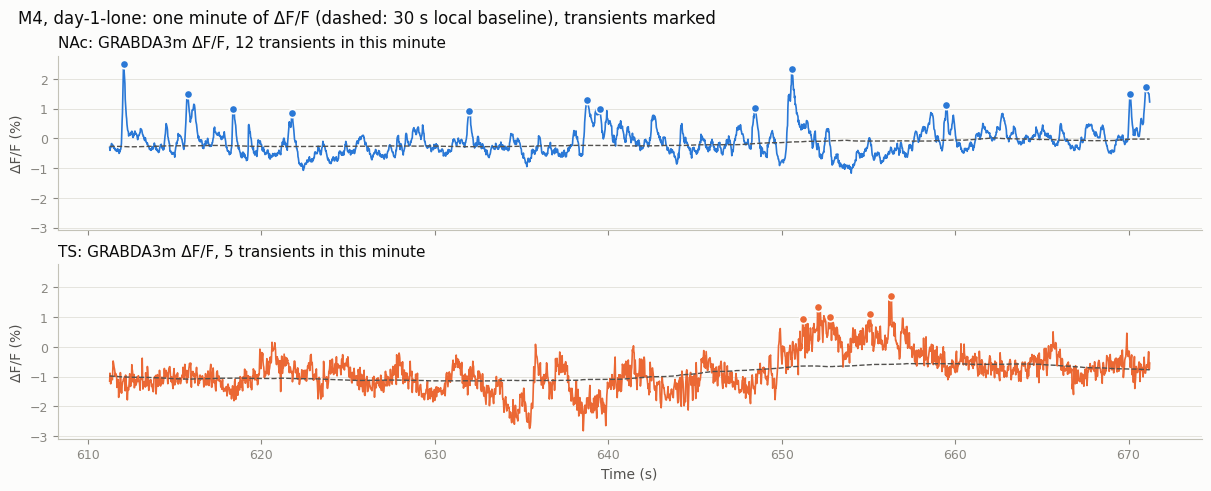

In [15]:
def local_baseline(trace, window_s=30.0):
    """Centered rolling median of a ΔF/F series over `window_s` seconds."""
    fs = 1.0 / np.median(np.diff(trace.index.to_numpy()))
    return trace.rolling(int(window_s * fs), center=True, min_periods=1).median()


def robust_z(x):
    median = np.median(x)
    mad = np.median(np.abs(x - median))
    return (x - median) / (1.4826 * mad)


def detect_transients(trace, z_threshold=3.0, min_separation_s=0.5, baseline_window_s=30.0):
    """Times of peaks whose robust z-score above the local baseline exceeds the threshold."""
    fs = 1.0 / np.median(np.diff(trace.index.to_numpy()))
    detrended = (trace - local_baseline(trace, baseline_window_s)).to_numpy()
    peaks, _ = find_peaks(
        robust_z(detrended), height=z_threshold, distance=max(1, int(min_separation_s * fs))
    )
    return trace.index.to_numpy()[peaks]


transients = {region: detect_transients(dff[region]) for region in REGION_COLORS}
duration_min = (dff.index[-1] - dff.index[0]) / 60
for region, times in transients.items():
    print(f"{REGION_SHORT[region]}: {len(times)} transients, {len(times) / duration_min:.1f} per minute")

zoom = (start + 600, start + 660)
fig, axes = plt.subplots(2, 1, figsize=(12, 4.8), sharex=True, sharey=True, constrained_layout=True)
for ax, region in zip(axes, REGION_COLORS):
    trace = dff.loc[zoom[0]:zoom[1], region]
    baseline = local_baseline(dff[region]).loc[zoom[0]:zoom[1]]
    ax.plot(trace.index, trace, color=REGION_COLORS[region], linewidth=1.2)
    ax.plot(baseline.index, baseline, color=INK_2, linewidth=1, linestyle="--")
    in_zoom = transients[region][(transients[region] >= zoom[0]) & (transients[region] <= zoom[1])]
    ax.plot(
        in_zoom, trace.loc[in_zoom], linestyle="none", marker="o",
        markersize=6, markerfacecolor=REGION_COLORS[region], markeredgecolor=SURFACE,
        markeredgewidth=1.2,
    )
    ax.set_title(f"{REGION_SHORT[region]}: GRABDA3m ΔF/F, {len(in_zoom)} transients in this minute")
    ax.set_ylabel("ΔF/F (%)")
axes[-1].set_xlabel("Time (s)")
fig.suptitle(
    f"{session_label}: one minute of ΔF/F (dashed: 30 s local baseline), transients marked",
    x=0.01, ha="left", color=INK,
)
plt.show()

### Every session side by side

The steps above can be combined into one function and applied to every photometry session in the database. For each session and region it reports:

- the length of the analysis window,
- the ΔF/F spread (median absolute deviation around the 30 s local baseline),
- the transient rate,
- the correlation between the NAc and TS ΔF/F traces, as one number per session.

Everything is looked up by session name. When new sessions are inserted, rerunning the notebook adds them to the checks, the table and the figure with no code changes.

In [16]:
def summarize_session(nwb_file_name):
    """Per-region ΔF/F summary for one session, fetched entirely through Spyglass."""
    dop_name = "FiberPhotometryInterpolatedDopamineSignal"
    t0, t1 = analysis_window(nwb_file_name, dop_name)
    dop = fetch_trace(nwb_file_name, dop_name).loc[t0:t1]
    ctl = fetch_trace(nwb_file_name, "FiberPhotometryInterpolatedControl").loc[t0:t1]
    session_dff = compute_dff(dop, ctl)
    minutes = (session_dff.index[-1] - session_dff.index[0]) / 60
    nac_ts_r = session_dff["Nucleus Accumbens"].corr(session_dff["Tail of Striatum"])
    rows = []
    for region in REGION_COLORS:
        detrended = (session_dff[region] - local_baseline(session_dff[region])).to_numpy()
        rows.append(
            {
                "nwb_file_name": nwb_file_name,
                "region": REGION_SHORT[region],
                "window_min": minutes,
                "dff_mad_pct": np.median(np.abs(detrended - np.median(detrended))),
                "transients_per_min": len(detect_transients(session_dff[region])) / minutes,
                "nac_ts_correlation": nac_ts_r,
            }
        )
    return rows


summary = pd.DataFrame(
    [row for name in sessions["nwb_file_name"] for row in summarize_session(name)]
).merge(sessions[["nwb_file_name", "subject_id", "session_id"]], on="nwb_file_name")
summary = summary[
    ["subject_id", "session_id", "region", "window_min", "dff_mad_pct",
     "transients_per_min", "nac_ts_correlation"]
]
summary.round(3)

,subject_id,session_id,region,window_min,dff_mad_pct,transients_per_min,nac_ts_correlation
0,M4,day-1-lone,NAc,29.969,0.249,13.681,0.025
1,M4,day-1-lone,TS,29.969,0.351,2.369,0.025
2,M4,day-2-lone,NAc,29.969,0.249,14.515,0.030
3,M4,day-2-lone,TS,29.969,0.765,3.504,0.030
4,M5,day-1-lone,NAc,29.969,0.189,10.644,0.560
5,M5,day-1-lone,TS,29.969,0.300,7.041,0.560
6,M7,day-1-lone,NAc,29.999,0.186,12.100,-0.266
7,M7,day-1-lone,TS,29.999,0.060,7.067,-0.266


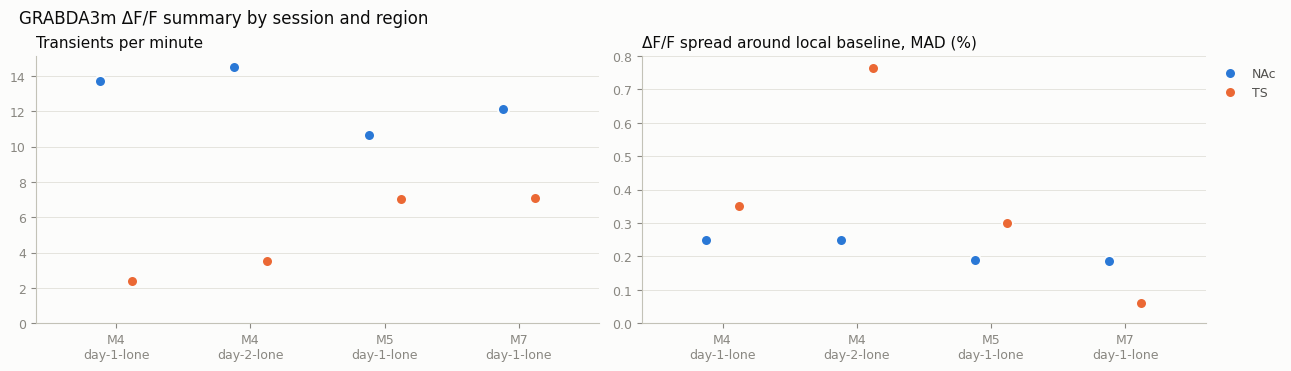

In [17]:
SHORT_COLORS = {REGION_SHORT[region]: color for region, color in REGION_COLORS.items()}
labels = (summary["subject_id"] + "\n" + summary["session_id"]).unique()
x_of = {label: i for i, label in enumerate(labels)}
offsets = {"NAc": -0.12, "TS": 0.12}
metrics = [
    ("transients_per_min", "Transients per minute"),
    ("dff_mad_pct", "ΔF/F spread around local baseline, MAD (%)"),
]

fig, axes = plt.subplots(
    1, len(metrics), figsize=(min(13, max(8, 1.6 * len(labels) * len(metrics))), 3.6),
    constrained_layout=True,
)
for ax, (metric, ylabel) in zip(axes, metrics):
    for region, group in summary.groupby("region"):
        xs = [x_of[f"{s}\n{d}"] + offsets[region] for s, d in zip(group["subject_id"], group["session_id"])]
        ax.plot(
            xs, group[metric], linestyle="none", marker="o", markersize=8,
            markerfacecolor=SHORT_COLORS[region], markeredgecolor=SURFACE, markeredgewidth=1.5,
            label=region,
        )
    ax.set_xticks(range(len(labels)), labels)
    ax.set_xlim(-0.6, len(labels) - 0.4)
    ax.set_ylim(bottom=0)
    ax.set_title(ylabel)
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
fig.suptitle("GRABDA3m ΔF/F summary by session and region", x=0.01, ha="left", color=INK)
plt.show()

## Summary

- **Queried from the database alone:** subject, session, hardware, reagents, implant sites with coordinates, each series with its sampling rate and valid times, and which fiber every trace column records.
- **Fetched through Spyglass:** the traces themselves, via `fetch1_dataframe()`, with no file paths in this notebook.
- **Worked with them:** confirmed the raw and camera-clock series share a clock, found a timestamp gap that `IntervalList` doesn't reflect, computed an illustrative ΔF/F, detected transients, and summarized every session in one table.

Only fiber photometry is ingested here. Pose (DANNCE), video and sync are in the NWB files but not in the database yet.